# 01 · Data and features

The event store, a token's life on the bonding curve, the exact curve math, online-vs-batch feature parity, and wallet / creator intelligence — all point-in-time.

> **Real data instead of the synthetic market.** Replace the generation cell with
> ```python
> from pumpfun_hft.collectors.storage import ParquetEventStore
> from pumpfun_hft.backtester.replay import load_metadata
> events = ParquetEventStore(settings.paths.events_dir).read()
> metadata = load_metadata(settings.paths.metadata_dir / "tokens.parquet")
> ```
> after running `collect-history` (or `stream`) from the CLI.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, polars as pl, matplotlib.pyplot as plt
from pumpfun_hft.core.config import load_settings
from pumpfun_hft.collectors.synthetic import SyntheticMarket

pl.Config.set_tbl_rows(12); pl.Config.set_tbl_cols(14); pl.Config.set_fmt_str_lengths(40); pl.Config.set_tbl_width_chars(160)
BLUE, ORANGE, AQUA, YELLOW, RED, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948", "#898781"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "axes.edgecolor": "#c3c2b7", "font.size": 9})


In [2]:
settings = load_settings(None, {"synthetic.duration_hours": 6})
market = SyntheticMarket(settings)
data = market.generate()                              # synthetic: plants informed wallets + serial ruggers
events, metadata, truth = data.events, data.metadata, data.truth
print(f"{events.height:,} events · {truth.height} launches · {int(truth['complete_ms'].is_not_null().sum())} graduations")
events.group_by("kind").len().sort("len", descending=True)

41,445 events · 157 launches · 0 graduations


kind,len
str,u32
"""trade""",41288
"""create""",157


## Every event, one schema
Swaps carry the reserves *after* the trade, the fee bps and amounts recorded on chain, and a total order `(slot, seq, ev_idx)`.

In [3]:
events.filter(pl.col("kind") == "trade").select("slot", "seq", "ts_ms", "mint", "user", "is_buy", "sol_amount",
                                                 "token_amount", "v_sol", "v_tok", "r_sol", "fee_bps", "fee").head(5)

slot,seq,ts_ms,mint,user,is_buy,sol_amount,token_amount,v_sol,v_tok,r_sol,fee_bps,fee
i64,i32,i64,str,str,bool,i64,i64,i64,i64,i64,i64,i64
350001137,1,1788221254802,"""3P83BsBWMWLYoev2pyv4mMBEVKtd9C42KN7uCj9q…","""7Ni2b7TP21wL3gezHmVH1cVzmRY4JR2Zy8kgjDjx…",true,2315988322,76898637440533,32315988322,996101362559467,2315988322,95,22001890
350001137,2,1788221254849,"""3P83BsBWMWLYoev2pyv4mMBEVKtd9C42KN7uCj9q…","""ExZ4rsZiZCCVzuKVQnnJanZJHnbECZ9FpFJJMY2u…",true,517538250,15701041277767,32833526572,980400321281700,2833526572,95,4916614
350001137,3,1788221254879,"""3P83BsBWMWLYoev2pyv4mMBEVKtd9C42KN7uCj9q…","""G7baUJVsSDyebJ5Wbv4BwDSMqtW1816B9V6wGjty…",true,825730701,24051233156649,33659257273,956349088125051,3659257273,95,7844442
350001137,4,1788221254891,"""3P83BsBWMWLYoev2pyv4mMBEVKtd9C42KN7uCj9q…","""HK8tAxx4DL32Kh85KMAeCgYEMUN5UCXtvPNDF6RF…",true,810708435,22492632546123,34469965708,933856455578928,4469965708,95,7701731
350001137,5,1788221254919,"""3P83BsBWMWLYoev2pyv4mMBEVKtd9C42KN7uCj9q…","""A1LecBp7PjDUaBrPrW2w3G1L8uFWP63cZ6VttkBS…",true,371060067,9945655481364,34841025775,923910800097564,4841025775,95,3525071


## A token's life
Price is `v_sol / v_tok` (SOL per whole token); real SOL liquidity is `r_sol`. On a bonding curve the price can never fall below the launch price, which is why rugs are labelled by **liquidity** drawdown, not price drawdown.

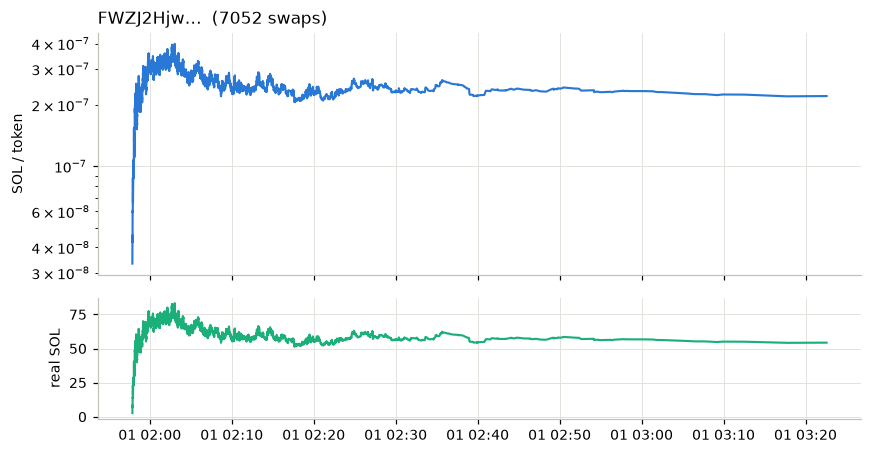

creator_kind,quality,viral,rugged,peak_multiple
str,f64,bool,bool,f64
"""neutral""",0.85,true,false,14.259236


In [4]:
top = (events.filter(pl.col("kind") == "trade").group_by("mint").len().sort("len", descending=True)["mint"][0])
tok = (events.filter((pl.col("mint") == top) & (pl.col("kind") == "trade"))
       .with_columns((pl.col("v_sol") / pl.col("v_tok") / 1000).alias("price"), (pl.col("r_sol") / 1e9).alias("liq"),
                     pl.from_epoch("ts_ms", time_unit="ms").alias("t")))
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
a1.plot(tok["t"], tok["price"], color=BLUE, lw=1.4); a1.set_ylabel("SOL / token"); a1.set_yscale("log")
a1.set_title(f"{top[:8]}…  ({tok.height} swaps)", loc="left")
a2.plot(tok["t"], tok["liq"], color=AQUA, lw=1.4); a2.set_ylabel("real SOL")
plt.tight_layout(); plt.show()
truth.filter(pl.col("mint") == top).select("creator_kind", "quality", "viral", "rugged", "peak_multiple")

## Exact curve math
Integer arithmetic identical to the on-chain program (verified against 792 golden cases from the official SDK). A round trip at launch costs the protocol + creator fee twice plus our own price impact.

In [5]:
from pumpfun_hft.core.curve import BondingCurve
curve = BondingCurve.from_config(settings.protocol.curve, settings.protocol.curve_fee_tiers)
st = curve.new_state(); fees = curve.fees_for(st)
buy = curve.buy_with_budget(st, 1_000_000_000, fees)                       # spend exactly 1 SOL
after = curve.apply_buy(st, buy)
sell = curve.sell_proceeds_for_tokens(after, buy.tokens, fees)
print(f"1 SOL buys {buy.tokens / 1e6:,.0f} tokens at {buy.avg_price:.3e} SOL each (spot {st.price:.3e})")
print(f"fees in: {(buy.protocol_fee + buy.creator_fee) / 1e9:.5f} SOL · immediate sell returns {sell.net / 1e9:.5f} SOL")
print(f"round-trip cost at launch: {100 * (1 - sell.net / buy.total):.2f} %")

1 SOL buys 34,199,203 tokens at 2.924e-08 SOL each (spot 2.796e-08)
fees in: 0.01235 SOL · immediate sell returns 0.97531 SOL
round-trip cost at launch: 2.47 %


## Online vs batch features: exact parity
Strategies use the online `FeatureEngine`; research uses the vectorised Polars pipeline. Both are computed from strictly past data, and they agree to floating-point precision.

In [6]:
from pumpfun_hft.features.replay import online_features
from pumpfun_hft.features.batch import batch_features
cols = ["buy_sol_short", "sell_sol_medium", "volume_sol_long", "imbalance_medium", "vwap_dist_medium",
        "ret_short", "ret_long", "progress_pct", "liquidity_sol", "age_s"]
online = online_features(settings, events, cols)
batch = batch_features(events, settings.features, settings.protocol.curve.initial_real_token_reserves)
pl.DataFrame({"feature": cols, "max_abs_diff": [float(np.nanmax(np.abs(online[c].to_numpy() - batch[c].to_numpy()))) for c in cols]})

feature,max_abs_diff
str,f64
"""buy_sol_short""",7.6206e-13
"""sell_sol_medium""",1.7053e-12
"""volume_sol_long""",8.3773e-12
"""imbalance_medium""",2.4712e-11
"""vwap_dist_medium""",1.1971e-10
"""ret_short""",0.0
"""ret_long""",0.0
"""progress_pct""",1.4211e-14
"""liquidity_sol""",1.4211e-14


## Wallet intelligence
Each wallet's *smart score* is the posterior probability that its realised round-trip edge is positive (shrunk towards zero for small samples), updated online. The synthetic market knows which wallets were planted as informed, so we can check the ranking.

In [7]:
from pumpfun_hft.backtester.engine import BacktestEngine
from pumpfun_hft.backtester.replay import DataSource
eng = BacktestEngine(settings, DataSource(frame=events), ["momentum_ignition"], metadata=metadata, synthetic=True)
res = eng.run()                                    # replays everything: wallet DB, creator book, outcomes
w = eng.wallets.to_frame(min_trades=3)
planted = {k: set(market.wallets.get(k, [])) for k in ("smart", "sniper", "bot", "whale")}   # ground truth
top = w.drop_nulls("smart_score").sort("smart_score", descending=True).head(50)
kinds = [next((k for k, s in planted.items() if a in s), "retail/other") for a in top["address"]]
print("planted class of the 50 highest-scored wallets:")
pl.Series("class", kinds).value_counts().sort("count", descending=True)

planted class of the 50 highest-scored wallets:


class,count
str,u32
"""sniper""",25
"""smart""",16
"""retail/other""",5
"""bot""",4


Informed wallets rank highly — but so do fast copy-trading bots and snipers, which are *profitable* in this market precisely because slower followers pay their impact. A high smart score says a wallet makes money, not that following it will.

In [8]:
outcomes = eng.resolver.to_frame().join(truth.select("mint", "creator_kind"), on="mint")
(outcomes.group_by("creator_kind").agg(pl.len(), (pl.col("label") == "rug").mean().alias("labelled_rug"),
                                       (pl.col("label") == "success").mean().alias("labelled_success"))
 .sort("creator_kind"))

creator_kind,len,labelled_rug,labelled_success
str,u32,f64,f64
"""legit""",13,0.0,0.692308
"""neutral""",62,0.096774,0.129032
"""rugger""",77,0.701299,0.012987


Outcomes are resolved one hour after each launch using only what happened until then; they feed the creator book (Beta posteriors) that strategies query point-in-time.